In [1]:
# General Libraries
import sys
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# GRU Model Libraries
import torch
import torch.nn as nn
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from torch.utils.data import TensorDataset, DataLoader

print("numpy:", np.__version__)
print("torch:", torch.__version__)

# Compatibility aliases for loading pickles created with NumPy 2.x
import numpy.core
import numpy.core.numeric
import numpy.core.multiarray
import numpy.core.umath

sys.modules["numpy._core"] = numpy.core
sys.modules["numpy._core.numeric"] = numpy.core.numeric
sys.modules["numpy._core.multiarray"] = numpy.core.multiarray
sys.modules["numpy._core.umath"] = numpy.core.umath 

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


numpy: 1.26.4
torch: 2.2.1+cu121
device: cuda


In [2]:
# Set seed of notebook for reproducibility
def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # More reproducible CUDA behavior
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

set_seed(0)

In [3]:
# Load battery dataset
bat_df = pd.read_pickle("data/bat_df.pkl")
print(bat_df.shape)

(124, 12)


In [4]:
# Splits from original paper
numBat1 = 41
numBat2 = 43
numBat3 = 40
numBat = numBat1 + numBat2 + numBat3

test_ind = np.hstack((np.arange(0, (numBat1 + numBat2), 2), 83))
train_ind = np.arange(1, (numBat1 + numBat2 - 1), 2)
secondary_test_ind = np.arange(numBat - numBat3, numBat)

train_df = bat_df.iloc[train_ind].reset_index(drop=True)
primary_test_df = bat_df.iloc[test_ind].reset_index(drop=True)
secondary_test_df = bat_df.iloc[secondary_test_ind].reset_index(drop=True)

print("train_df:", train_df.shape)
print("primary_test_df:", primary_test_df.shape)
print("secondary_test_df:", secondary_test_df.shape)

train_df: (41, 12)
primary_test_df: (43, 12)
secondary_test_df: (40, 12)


In [5]:
# Directly fix outlier QD: b1c18, cycle 40
idx = primary_test_df.index[primary_test_df["battery_id"] == "b1c18"][0]
QD = primary_test_df.at[idx, "QD"].copy()
QD[39] = 0.5 * (QD[38] + QD[40])   # cycle_idx 39 = cycle 40
primary_test_df.at[idx, "QD"] = QD

# Directly fix outlier QD: b1c0, cycle 12
idx = primary_test_df.index[primary_test_df["battery_id"] == "b1c0"][0]
QD = primary_test_df.at[idx, "QD"].copy()
QD[11] = 0.5 * (QD[10] + QD[12])   # cycle_idx 11 = cycle 12
primary_test_df.at[idx, "QD"] = QD

In [6]:
# Build GRU dataset using Qdlin_cycle_X - Qdlin_cycle_10 every 5 cycles from 20 to 100
def build_gru_arrays(df, split_name):
    X_list = []
    y_list = []
    battery_ids = []

    # For each battery
    for _, row in df.iterrows():

        battery_tensor = []

        # Get cycle 10 qdlin
        q_10 = np.asarray(row["cycles"]["9"]["Qdlin"], dtype=float).squeeze()

        # Get cycle qdlin changes for all cycles for current battery
        for cyc_idx in range(19, 100, 5):
            q_curr = np.asarray(row["cycles"][str(cyc_idx)]["Qdlin"], dtype=float).squeeze()
            dq = q_curr - q_10
            battery_tensor.append(dq)

        # Shape: [selected_cycles, voltage]
        battery_tensor = np.stack(battery_tensor, axis=0)

        X_list.append(battery_tensor)
        y_list.append(np.log10(row["cycle_life"]))
        battery_ids.append(row["battery_id"])

    X = np.stack(X_list, axis=0).astype(np.float32)
    y = np.asarray(y_list, dtype=np.float32).reshape(-1, 1)

    print(split_name)
    print("X shape:", X.shape)
    print("y shape:", y.shape)

    return X, y, battery_ids


X_train, y_train, train_ids = build_gru_arrays(train_df, "train")
X_primary, y_primary, primary_ids = build_gru_arrays(primary_test_df, "primary_test")
X_secondary, y_secondary, secondary_ids = build_gru_arrays(secondary_test_df, "secondary_test")

train
X shape: (41, 17, 1000)
y shape: (41, 1)
primary_test
X shape: (43, 17, 1000)
y shape: (43, 1)
secondary_test
X shape: (40, 17, 1000)
y shape: (40, 1)


In [7]:
# Normalize each voltage coordinate indepedently (different from FNO global scaling)
# 2 Modes: Train + Validation (During Cross Validation) and Train + Primary Test + Secondary Test (During final model evaluation)
def scale_voltage_features(X_train, X_val, X_test=None):

    scalers = []

    X_train_scaled = np.zeros_like(X_train)
    X_val_scaled = np.zeros_like(X_val)

    if X_test is not None:
        X_test_scaled = np.zeros_like(X_test)

    # For all 1000 voltage points
    for v in range(1000):

        scaler = StandardScaler()

        # Extract all data for that voltage point
        train_feat = X_train[:, :, v]

        scaler.fit(train_feat.reshape(-1, 1))

        X_train_scaled[:, :, v] = (
            scaler.transform(
                train_feat.reshape(-1, 1)
            ).reshape(train_feat.shape)
        )

        val_feat = X_val[:, :, v]

        X_val_scaled[:, :, v] = (
            scaler.transform(
                val_feat.reshape(-1, 1)
            ).reshape(val_feat.shape)
        )

        # If during final evaluation
        if X_test is not None:

            test_feat = X_test[:, :, v]

            X_test_scaled[:, :, v] = (
                scaler.transform(
                    test_feat.reshape(-1, 1)
                ).reshape(test_feat.shape)
            )

        scalers.append(scaler)

    # If during final evaluation
    if X_test is not None:
        return X_train_scaled, X_val_scaled, X_test_scaled, scalers
        
    return X_train_scaled, X_val_scaled, scalers

In [8]:
# Curve Encoder + GRU model
class CurveGRU(nn.Module):

    def __init__(
        self,
        curve_latent_dim=128,
        hidden_size=128,
        num_layers=2,
        dropout=0.2
    ):

        super().__init__()

        # Create Curve Encoder
        self.curve_encoder = nn.Sequential(
            nn.Linear(1000, 512),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(512, curve_latent_dim),
            nn.ReLU()
        )

        # Create GRU (use prebuilt GRU model)
        self.gru = nn.GRU(
            input_size=curve_latent_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        # Create final regressor head
        self.regressor = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        
        # x shape: [batch, cycles, voltage]
        B, T, V = x.shape

        # Flatten cycles into batch dimension
        x = x.reshape(B * T, V)

        # Encode each curve
        x = self.curve_encoder(x)

        # Reshape back to original
        x = x.reshape(B, T, -1)

        # Get prediction using final timestep
        out, _ = self.gru(x)
        out = out[:, -1, :]
        out = self.regressor(out)

        return out

In [9]:
# Training function

def train_model(model, train_loader, val_loader, lr, weight_decay, epochs):

    criterion = nn.HuberLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    best_val_loss = np.inf
    best_state = None

    train_losses = []
    val_losses = []

    model.to(device)

    # Train for number of epochs
    for epoch in range(epochs):

        # Training

        model.train()

        running_train_loss = 0.0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            preds = model(X_batch)

            loss = criterion(preds, y_batch)

            loss.backward()

            optimizer.step()

            running_train_loss += loss.item()

        avg_train_loss = running_train_loss/ len(train_loader)

        # Validation

        model.eval()

        running_val_loss = 0.0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                preds = model(X_batch)

                loss = criterion(preds, y_batch)

                running_val_loss += loss.item()

        avg_val_loss = running_val_loss / len(val_loader)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        # Early stopping
        improvement = best_val_loss - avg_val_loss
        if improvement > 1e-4:

            best_val_loss = avg_val_loss

            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        if epoch % 20 == 0:
            print(f"Epoch {epoch:3d} | Train {avg_train_loss:.6f} | Val {avg_val_loss:.6f}")

    model.load_state_dict(best_state)

    return model, train_losses, val_losses

In [10]:
# Compute Mean Absolute Percentage Error (MAPE)
def compute_mape(model, X_tensor, y_tensor):

    model.eval()

    X_tensor = X_tensor.to(device)

    with torch.no_grad():
        preds_log = model(X_tensor).cpu().numpy().flatten()

    preds = 10 ** preds_log
    y_true = 10 ** y_tensor.cpu().numpy().flatten()

    mape = np.mean(np.abs(preds - y_true) / y_true) * 100
    return mape

# K-fold Cross-validation (K=4 like the paper)
def cross_validate_model(config, X, y, n_splits):

    # Create folds
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    fold_mapes = []

    # Loop through fold splits
    for fold, (train_idx, val_idx) in enumerate( kf.split(X)):

        print(f"\nFold {fold+1}/{n_splits}")

        X_train_fold = X[train_idx]
        X_val_fold = X[val_idx]

        y_train_fold = y[train_idx]
        y_val_fold = y[val_idx]

        # Cross Validation feating scaling on train and validation sets
        X_train_scaled, X_val_scaled, _ = scale_voltage_features(X_train_fold, X_val_fold)

        # Creat tensors
        X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
        X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
        y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32)
        y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32)

        # Create dataloaders for model input
        # Set generator seed for reproducibility
        g = torch.Generator()
        g.manual_seed(0)
        
        train_loader = DataLoader(
            TensorDataset(X_train_tensor, y_train_tensor),
            batch_size=16,
            shuffle=True,
            generator=g
        )

        val_loader = DataLoader(
            TensorDataset(X_val_tensor, y_val_tensor),
            batch_size=16,
            shuffle=False,
            generator=g
        )

        # Create Curve GRU model
        model = CurveGRU(
            curve_latent_dim=config["curve_latent_dim"],
            hidden_size=config["hidden_size"],
            num_layers=config["num_layers"],
            dropout=config["dropout"]
        )

        # Train GRU model
        model, _, _ = train_model(
            model,
            train_loader,
            val_loader,
            lr=config["lr"],
            weight_decay=config["weight_decay"],
            epochs=config["epochs"],
        )

        # MAPE calculation
        fold_mape = compute_mape(model, X_val_tensor, y_val_tensor)
        print(f"Fold MAPE: {fold_mape:.2f}%")
        
        fold_mapes.append(fold_mape)

    return np.mean(fold_mapes)

In [20]:
## GRU hyperparameter search
search_space = [
    {
        "curve_latent_dim": 256,
        "hidden_size": 256,
        "num_layers": 3,
        "dropout": 0.2,
        "lr": 1e-4,
        "weight_decay": 1e-5,
        "epochs": 200,
    },

    {
        "curve_latent_dim": 64,
        "hidden_size": 32,
        "num_layers": 2,
        "dropout": 0.3,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "epochs": 300,
    },

    {
        "curve_latent_dim": 128,
        "hidden_size": 128,
        "num_layers": 1,
        "dropout": 0.1,
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "epochs": 300,
    }
]

best_config = None
best_cv_mape = np.inf

for config in search_space:

    print("\n===================================")
    print(config)

    cv_mape = cross_validate_model(config, X_train, y_train, n_splits=4)
    print(f"\nMean CV MAPE: {cv_mape:.2f}%")

    if cv_mape < best_cv_mape:

        best_cv_mape = cv_mape
        best_config = config

print("\nBEST CONFIG")
print(best_config)

print("\nBEST CV MAPE")
print(best_cv_mape)


{'curve_latent_dim': 256, 'hidden_size': 256, 'num_layers': 3, 'dropout': 0.2, 'lr': 0.0001, 'weight_decay': 1e-05, 'epochs': 200}

Fold 1/4
Epoch   0 | Train 2.187404 | Val 2.095458
Epoch  20 | Train 0.082621 | Val 0.081613
Epoch  40 | Train 0.024941 | Val 0.012618
Epoch  60 | Train 0.013040 | Val 0.008970
Epoch  80 | Train 0.014567 | Val 0.003414
Epoch 100 | Train 0.013443 | Val 0.003346
Epoch 120 | Train 0.011805 | Val 0.005076
Epoch 140 | Train 0.012173 | Val 0.006132
Epoch 160 | Train 0.007042 | Val 0.005654
Epoch 180 | Train 0.009960 | Val 0.005003
Fold MAPE: 14.74%

Fold 2/4
Epoch   0 | Train 2.291606 | Val 2.346086
Epoch  20 | Train 0.165922 | Val 0.140311
Epoch  40 | Train 0.016333 | Val 0.022282
Epoch  60 | Train 0.012401 | Val 0.021559
Epoch  80 | Train 0.014796 | Val 0.021900
Epoch 100 | Train 0.011460 | Val 0.021549
Epoch 120 | Train 0.015626 | Val 0.022310
Epoch 140 | Train 0.014560 | Val 0.021362
Epoch 160 | Train 0.009581 | Val 0.020380
Epoch 180 | Train 0.015392 | Val

In [21]:
# Re-train model using all training data

# Scale every voltage point for all final data before evaluation
X_train_scaled, X_primary_scaled, X_secondary_scaled, _ = scale_voltage_features(X_train, X_primary, X_secondary)

# Create final tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_primary_tensor = torch.tensor(X_primary_scaled, dtype=torch.float32)
X_secondary_tensor = torch.tensor(X_secondary_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

# Set generator seed for reproducibility
g = torch.Generator()
g.manual_seed(0)
set_seed(0)

full_loader = DataLoader(
    TensorDataset(X_train_tensor, y_train_tensor),
    batch_size=16,
    shuffle=True,
    generator=g
    
)

# Create final Curve GRU model
best_model = CurveGRU(
    curve_latent_dim=best_config["curve_latent_dim"],
    hidden_size=best_config["hidden_size"],
    num_layers=best_config["num_layers"],
    dropout=best_config["dropout"]
)

best_model, train_losses, _ = train_model(
    best_model,
    full_loader,
    full_loader,
    lr=best_config["lr"],
    weight_decay=best_config["weight_decay"],
    epochs=800,
)

Epoch   0 | Train 1.912253 | Val 1.127735
Epoch  20 | Train 0.014666 | Val 0.007021
Epoch  40 | Train 0.008907 | Val 0.004137
Epoch  60 | Train 0.011215 | Val 0.003729
Epoch  80 | Train 0.007547 | Val 0.003823
Epoch 100 | Train 0.007083 | Val 0.002187
Epoch 120 | Train 0.008252 | Val 0.001888
Epoch 140 | Train 0.009216 | Val 0.002327
Epoch 160 | Train 0.005089 | Val 0.002375
Epoch 180 | Train 0.003676 | Val 0.001021
Epoch 200 | Train 0.004915 | Val 0.001185
Epoch 220 | Train 0.004965 | Val 0.003643
Epoch 240 | Train 0.004503 | Val 0.000807
Epoch 260 | Train 0.004705 | Val 0.000997
Epoch 280 | Train 0.004685 | Val 0.001053
Epoch 300 | Train 0.003428 | Val 0.001073
Epoch 320 | Train 0.007533 | Val 0.001080
Epoch 340 | Train 0.004668 | Val 0.002709
Epoch 360 | Train 0.004748 | Val 0.001965
Epoch 380 | Train 0.006651 | Val 0.006115
Epoch 400 | Train 0.004852 | Val 0.000626
Epoch 420 | Train 0.005081 | Val 0.001478
Epoch 440 | Train 0.004480 | Val 0.002635
Epoch 460 | Train 0.005943 | Val 0

,split,rmse_cycles,mean_percent_error
0,train,45.660294,3.724106
1,primary_test,96.479416,12.407005
2,secondary_test,224.968369,16.407272


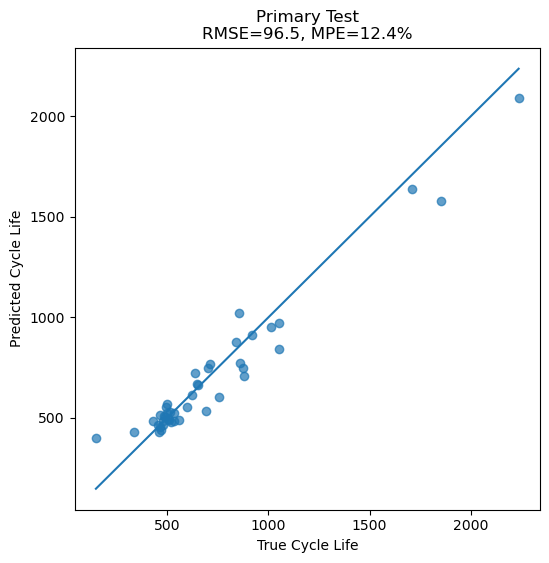

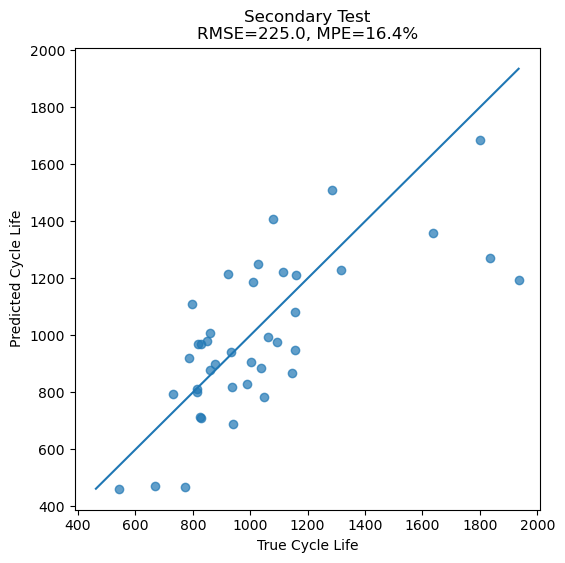

In [22]:
# Create prediction function
def predict(model, X_tensor):

    model.eval()

    X_tensor = X_tensor.to(device)

    with torch.no_grad():
        preds_log = model(X_tensor).cpu().numpy().flatten()

    return preds_log

# Use prediction function to make prediction on each set
train_pred_log = predict(best_model, X_train_tensor)
primary_pred_log = predict(best_model, X_primary_tensor)
secondary_pred_log = predict(best_model, X_secondary_tensor)

train_pred = 10 ** train_pred_log
primary_pred = 10 ** primary_pred_log
secondary_pred = 10 ** secondary_pred_log

train_true = 10 ** y_train.flatten()
primary_true = 10 ** y_primary.flatten()
secondary_true = 10 ** y_secondary.flatten()

# Calculate final metrics
train_rmse = np.sqrt(mean_squared_error(train_true, train_pred))
primary_rmse = np.sqrt(mean_squared_error(primary_true, primary_pred))
secondary_rmse = np.sqrt(mean_squared_error(secondary_true, secondary_pred))

train_mpe = np.mean(np.abs(train_pred - train_true) / train_true) * 100
primary_mpe = np.mean(np.abs(primary_pred - primary_true) / primary_true) * 100
secondary_mpe = np.mean(np.abs(secondary_pred - secondary_true) / secondary_true) * 100

# Summary table

summary_df = pd.DataFrame({
    "split": ["train", "primary_test", "secondary_test"],
    "rmse_cycles": [train_rmse, primary_rmse, secondary_rmse],
    "mean_percent_error": [train_mpe, primary_mpe, secondary_mpe]
})

display(summary_df)

# Primary test plot
plt.figure(figsize=(6,6))

plt.scatter(
    primary_true,
    primary_pred,
    alpha=0.7
)

lims = [
    min(primary_true.min(), primary_pred.min()),
    max(primary_true.max(), primary_pred.max())
]

plt.plot(lims, lims)
plt.xlabel("True Cycle Life")
plt.ylabel("Predicted Cycle Life")
plt.title(f"Primary Test\nRMSE={primary_rmse:.1f}, MPE={primary_mpe:.1f}%")
plt.show()

# Secondary test plot
plt.figure(figsize=(6,6))

plt.scatter(
    secondary_true,
    secondary_pred,
    alpha=0.7
)

lims = [
    min(secondary_true.min(), secondary_pred.min()),
    max(secondary_true.max(), secondary_pred.max())
]

plt.plot(lims, lims)

plt.xlabel("True Cycle Life")
plt.ylabel("Predicted Cycle Life")
plt.title(f"Secondary Test\nRMSE={secondary_rmse:.1f}, MPE={secondary_mpe:.1f}%")
plt.show()

In [23]:
# Get ground truth + prediction for every battery
def make_gru_results(battery_ids, true_cycle_life, pred_cycle_life):
    battery_ids = np.asarray(battery_ids).ravel()
    true_cycle_life = np.asarray(true_cycle_life).ravel()
    pred_cycle_life = np.asarray(pred_cycle_life).ravel()

    return pd.DataFrame({
        "battery_id": battery_ids,
        "true_cycle_life": true_cycle_life,
        "pred_cycle_life": pred_cycle_life,
        "abs_percent_error": (np.abs(pred_cycle_life - true_cycle_life) / true_cycle_life * 100)
    })


train_gru_results = make_gru_results(train_ids, train_true, train_pred)
primary_gru_results = make_gru_results(primary_ids, primary_true, primary_pred)
secondary_gru_results = make_gru_results(secondary_ids, secondary_true, secondary_pred)

display(HTML("<h3>Train Set GRU Results</h3>"))
display(train_gru_results)

display(HTML("<h3>Primary Test Set GRU Results</h3>"))
display(primary_gru_results)

display(HTML("<h3>Secondary Test Set GRU Results</h3>"))
display(secondary_gru_results)

,battery_id,true_cycle_life,pred_cycle_life,abs_percent_error
0,b1c1,2160.000244,2298.248779,6.400394
1,b1c3,1434.000244,1587.063110,10.673838
2,b1c5,1073.999756,1156.645386,7.695126
3,b1c7,869.999817,924.731323,6.290979
4,b1c11,788.000244,818.075989,3.816718
5,b1c15,718.999817,767.197205,6.703394
6,b1c17,856.999878,835.516663,2.506793
7,b1c19,788.000244,701.622009,10.961701
8,b1c21,558.999878,589.651978,5.483382
9,b1c24,1016.999817,1006.969299,0.986285


,battery_id,true_cycle_life,pred_cycle_life,abs_percent_error
0,b1c0,1852.000366,1579.011353,14.740224
1,b1c2,2236.999512,2089.449463,6.595891
2,b1c4,1709.000000,1640.148193,4.028778
3,b1c6,635.999817,722.724548,13.635967
4,b1c9,1053.999756,843.936584,19.930098
5,b1c14,879.999817,708.783691,19.456383
6,b1c16,862.000061,772.990784,10.325901
7,b1c18,691.000000,536.181946,22.404928
8,b1c20,533.999939,523.990784,1.874374
9,b1c23,1014.000000,950.256104,6.286380


,battery_id,true_cycle_life,pred_cycle_life,abs_percent_error
0,b3c0,1009.000122,1188.527100,17.792562
1,b3c1,1063.000244,995.023315,6.394818
2,b3c3,1114.999878,1223.703735,9.749227
3,b3c4,1047.999756,784.911072,25.103888
4,b3c5,827.999878,971.194275,17.294012
5,b3c6,666.999939,470.382111,29.477940
6,b3c7,1835.999756,1271.602173,30.740612
7,b3c8,827.999878,710.998413,14.130613
8,b3c9,1039.000244,884.514832,14.868660
9,b3c10,1078.000000,1408.629517,30.670643
